In [1]:
import numpy as np
from scipy.special import softmax
import pandas as pd
import seaborn as sns
import pylab as pl
from scipy.optimize import minimize, differential_evolution
import belief_mix_model as bmm
from scipy.spatial.distance import cdist,pdist,euclidean
from collections import Counter
import scipy as sp

In [2]:
data_dir = "../Lucas_Cecile/"
fig_dir = "./figures/brinkman_board/"

In [3]:
processed_data = pd.read_csv(data_dir+"extracted_trajs.csv")


In [4]:
ps = "with_beta_wo_effort"

In [5]:
# fittings = pd.read_csv(data_dir+"fittings__with_beta.csv")
# fittings = pd.read_csv(data_dir+"fittings_wo_effort.csv")
fittings = pd.read_csv(data_dir+"fittings_"+ps+".csv")


In [6]:
fittings

,Unnamed: 0,Subject,Phase,Species,spatial_bias,LL,W(spatial_bias),W(reward),W(memory),reward_influence,memory_recall ($\lambda$),beta
0,0,Amidala,Habituation,Macaca_mulatta,row_scan,268.718961,0.399862,2.409234,5.000000,1.584833,0.990000,0.189091
1,0,Amidala,Post-test,Macaca_mulatta,row_scan,255.230811,0.860739,0.000000,4.204327,1.066151,0.990000,0.473253
2,0,Amidala,Test,Macaca_mulatta,spiral,582.872982,0.513842,0.844644,3.708172,1.058519,0.908102,0.172490
3,0,Anyanka,Habituation,Macaca_mulatta,random,242.469642,0.144250,0.368880,2.953853,1.714511,0.897106,1.557701
4,0,Anyanka,Post-test,Macaca_mulatta,column_scan,257.487367,0.035932,0.365813,4.673269,0.993412,0.913328,0.573496
5,0,Anyanka,Test,Macaca_mulatta,column_scan,568.636530,0.547529,0.802604,3.414782,0.508485,0.943243,0.230804
6,0,Arwen,Habituation,Macaca_mulatta,spiral,249.986188,0.000000,0.000000,5.000000,2.463907,0.990000,5.000000
7,0,Arwen,Post-test,Macaca_mulatta,column_scan,265.585661,0.000000,0.000000,3.430244,2.962438,0.914230,0.592634
8,0,Arwen,Test,Macaca_mulatta,spiral,590.745011,2.696399,0.000000,4.075153,2.692074,0.990000,0.135912
9,0,Dory,Habituation,Macaca_tonkeana,row_scan,221.948667,0.680816,0.000000,3.424891,0.617198,0.990000,0.329791


In [7]:
processed_data

,Unnamed: 0,Behavior,Rows,Cols,Reward,Time,PST_condition,Subject,Session,Phase,Species
0,0,D2,1,3,0,13.28,Transparent,Amidala,1,Habituation,Macaca_mulatta
1,1,E3,2,4,0,17.32,Transparent,Amidala,1,Habituation,Macaca_mulatta
2,2,E2,1,4,0,20.88,Transparent,Amidala,1,Habituation,Macaca_mulatta
3,3,D5,4,3,0,25.24,Transparent,Amidala,1,Habituation,Macaca_mulatta
4,4,C5,4,2,0,29.20,Transparent,Amidala,1,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...,...,...
5035,15,C1,0,2,0,34.76,Transparent,Yin,20,Post-test,Macaca_tonkeana
5036,16,B1,0,1,0,36.36,Transparent,Yin,20,Post-test,Macaca_tonkeana
5037,17,C3,2,2,0,38.50,Transparent,Yin,20,Post-test,Macaca_tonkeana
5038,18,B4,3,1,0,40.22,Transparent,Yin,20,Post-test,Macaca_tonkeana


In [8]:
fittings.columns

Index(['Unnamed: 0', 'Subject', 'Phase', 'Species', 'spatial_bias', 'LL',
       'W(spatial_bias)', 'W(reward)', 'W(memory)', 'reward_influence',
       'memory_recall ($\lambda$)', 'beta'],
      dtype='object')

In [15]:
# Save the generated and actual trajectories
compare_trajs = pd.DataFrame()
compare_stats = pd.DataFrame()
compare_dist_trajs = pd.DataFrame()
compare_visit_map = pd.DataFrame()

for grp in fittings.groupby(['Subject','Phase','Species']):
    if ps == 'wo_effort':
        wK, wR, wM, sigma, decay = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0]
    elif ps == 'with_beta_wo_effort':
        wK, wR, wM, sigma, decay,beta = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0],grp[1]['beta'].values[0]
    else:
#     wK, wR, wM,wE, sigma, decay,beta = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['W(effort)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_decay ($\lambda$)'].values[0],grp[1]['beta'].values[0]
        wK, wR, wM,wE, sigma, decay,beta = grp[1]['W(spatial_bias)'].values[0], grp[1]['W(reward)'].values[0],grp[1]['W(memory)'].values[0],grp[1]['W(effort)'].values[0],grp[1]['reward_influence'].values[0],grp[1]['memory_recall ($\lambda$)'].values[0],grp[1]['beta'].values[0]
    
    sim_trajs = []
    act_data = processed_data.loc[(processed_data['Subject']==grp[0][0])&(processed_data['Phase']==grp[0][1])&(processed_data['Species']==grp[0][2])].copy()
    act_trajs = [ [[x,y]  for x,y in zip(tr[1].Rows,tr[1].Cols)] for tr in act_data.groupby('Session') ]
    
    Nsim = len(act_trajs)
    stats_act = dict({'revisit_rate':[],'traj_num':[],'jump_length':[],'first_revisit':[],'total_dist':[]})
    stats_sim = dict({'revisit_rate':[],'traj_num':[],'jump_length':[],'first_revisit':[],'total_dist':[]})
    
    dist_between_trajs = []
    corr_between_trajs = []
    
    for i,traj in enumerate(act_trajs):

        start = traj[0]
#        for i in range(Nsim):
        if ps == 'wo_effort':
                    sim, _, _, _ = bmm.simulate_case(
            kernel_type=grp[1]['spatial_bias'].values[0],
            start_loc=start,
            T=len(traj)-1,
            sigma=sigma,
            decay=decay,
            wK=wK,
            wR=wR,
            wM=wM,
               
            )
        elif ps == "with_beta_wo_effort":
            sim, _, _, _ = bmm.simulate_case(
                kernel_type=grp[1]['spatial_bias'].values[0],
                start_loc=start,
                T=len(traj)-1,
                sigma=sigma,
                decay=decay,
                wK=wK,
                wR=wR,
                wM=wM,
#                 wE=wE,
                beta=beta
            )
            
            
        else:
        
            sim, _, _, _ = bmm.simulate_case(
                kernel_type=grp[1]['spatial_bias'].values[0],
                start_loc=start,
                T=len(traj)-1,
                sigma=sigma,
                decay=decay,
                wK=wK,
                wR=wR,
                wM=wM,
                wE=wE,
                beta=beta
            )

        sim_trajs.append(sim)    
        
        revis_act, first_rev_act = bmm.revisit_rate(traj)
        revis_sim,first_rev_sim = bmm.revisit_rate(sim)
        
        mean_jump_act, var_jump_act, tot_jump_act = bmm.jump_lengths(traj)
        mean_jump_sim, var_jump_sim, tot_jump_sim = bmm.jump_lengths(sim)
        
        tot_dist_act = bmm.calc_total_distance_covered(traj)
        tot_dist_sim = bmm.calc_total_distance_covered(sim)
        
        stats_act['revisit_rate'].append(revis_act)
        stats_act['jump_length'].append(mean_jump_act)
        stats_act['first_revisit'].append(first_rev_act)
        stats_act['total_dist'].append(tot_dist_act)
        stats_act['traj_num'].append(i)
        
        stats_sim['revisit_rate'].append(revis_sim)
        stats_sim['jump_length'].append(mean_jump_sim)
        stats_sim['first_revisit'].append(first_rev_sim)
        stats_sim['total_dist'].append(tot_dist_sim)
        stats_sim['traj_num'].append(i)
        
        dist,corr = bmm.calc_dist_bw_traj(traj,sim)
        dist_between_trajs.append(dist)
#         corr_between_trajs.append(corr)
        
    
    Vobs = sum(bmm.visit_map(t) for t in act_trajs)
    Vsim = sum(bmm.visit_map(t) for t in sim_trajs)
    
#     Vobs = Vobs/np.max(Vobs)
#     Vsim = Vsim/np.max(Vsim)
    Vobs_df = pd.DataFrame(Vobs,columns=np.arange(1,6),index=np.arange(1,6))
    Vobs_df['type'] = 'data'
    
    Vsim_df = pd.DataFrame(Vsim,columns=np.arange(1,6),index=np.arange(1,6))
    Vsim_df['type'] = 'model'
    
    Vmap = pd.concat([Vobs_df,Vsim_df])
    Vmap['Subject'] = grp[0][0]
    Vmap['Phase'] = grp[0][1]
    Vmap['Species'] = grp[0][2]
    
    compare_visit_map = pd.concat([compare_visit_map,Vmap])
    
    
    stats_act_df = pd.DataFrame(stats_act)
    stats_act_df['type'] = 'data'
    
    stats_sim_df = pd.DataFrame(stats_sim)
    stats_sim_df['type'] = 'model'
    to_add = pd.concat([stats_act_df,stats_sim_df])
    to_add['Subject'] = grp[0][0]
    to_add['Phase'] = grp[0][1]
    to_add['Species'] = grp[0][2]
    
    compare_stats = pd.concat([compare_stats,to_add])
    
    temp_df = pd.DataFrame()
    temp_df['dist_traj(model,data)'] = dist_between_trajs
#     temp_df['corr_traj(model_data)'] = corr_between_trajs
    temp_df['Subject'] = grp[0][0]
    temp_df['Phase'] = grp[0][1]
    temp_df['Species'] = grp[0][2]
    
    compare_dist_trajs = pd.concat([compare_dist_trajs,temp_df])
    

    
        
        
    
    temp = pd.DataFrame()
    temp['Rows_model'] = np.array(sim_trajs)[:,:,0].flatten()
    temp['Cols_model'] = np.array(sim_trajs)[:,:,1].flatten()
   
    temp['Rows_data'] = np.array(act_trajs)[:,:,0].flatten()
    temp['Cols_data'] = np.array(act_trajs)[:,:,1].flatten()
    temp['Subject'] = grp[0][0]
    temp['Phase'] = grp[0][1]
    temp['Species'] = grp[0][2]
    temp['spatial_bias'] = grp[1]['spatial_bias'].values[0]
    compare_trajs = pd.concat([compare_trajs,temp])
    
    

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

In [16]:
traj

[[4, 1],
 [4, 3],
 [4, 4],
 [3, 4],
 [3, 3],
 [2, 3],
 [3, 2],
 [3, 1],
 [3, 0],
 [2, 1],
 [1, 1],
 [0, 1],
 [0, 3],
 [1, 3],
 [2, 3],
 [4, 3],
 [2, 2],
 [3, 4],
 [4, 4],
 [1, 4]]

In [17]:
compare_dist_trajs

,"dist_traj(model,data)",Subject,Phase,Species
0,47.936151,Amidala,Habituation,Macaca_mulatta
1,43.158210,Amidala,Habituation,Macaca_mulatta
2,49.315287,Amidala,Habituation,Macaca_mulatta
3,43.450823,Amidala,Habituation,Macaca_mulatta
4,50.764625,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...
5,47.847664,Yin,Test,Macaca_tonkeana
6,38.942922,Yin,Test,Macaca_tonkeana
7,56.602507,Yin,Test,Macaca_tonkeana
8,49.457602,Yin,Test,Macaca_tonkeana


In [18]:
grp[1]

,Unnamed: 0,Subject,Phase,Species,spatial_bias,LL,W(spatial_bias),W(reward),W(memory),reward_influence,memory_recall ($\lambda$),beta
41,0,Yin,Test,Macaca_tonkeana,row_scan,588.433901,0.932747,2.120194,1.346703,1.810306,0.759706,0.178931


In [19]:
# compare_stats.to_csv(data_dir+"compare_stats_wo_effort.csv")
compare_stats.to_csv(data_dir+"compare_stats"+ps+".csv")
# compare_trajs.to_csv(data_dir+"compare_trajs_wo_effort.csv")
compare_trajs.to_csv(data_dir+"compare_trajs"+ps+".csv")

compare_dist_trajs.to_csv(data_dir+"compare_dist_between_trajs.csv")

In [20]:
compare_stats

,revisit_rate,traj_num,jump_length,first_revisit,total_dist,type,Subject,Phase,Species
0,0.00,0,1.631579,0,25.883627,data,Amidala,Habituation,Macaca_mulatta
1,0.10,1,1.894737,14,29.963990,data,Amidala,Habituation,Macaca_mulatta
2,0.05,2,2.000000,15,31.896819,data,Amidala,Habituation,Macaca_mulatta
3,0.10,3,2.105263,7,34.712101,data,Amidala,Habituation,Macaca_mulatta
4,0.05,4,1.947368,19,31.491901,data,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...
5,0.20,5,2.789474,6,44.093715,model,Yin,Test,Macaca_tonkeana
6,0.10,6,2.789474,10,42.887524,model,Yin,Test,Macaca_tonkeana
7,0.40,7,3.105263,5,48.279297,model,Yin,Test,Macaca_tonkeana
8,0.30,8,2.736842,4,42.359660,model,Yin,Test,Macaca_tonkeana


In [21]:
compare_visit_map

,1,2,3,4,5,type,Subject,Phase,Species
1,0.0,1.0,3.0,2.0,2.0,data,Amidala,Habituation,Macaca_mulatta
2,2.0,4.0,5.0,5.0,4.0,data,Amidala,Habituation,Macaca_mulatta
3,5.0,6.0,5.0,4.0,5.0,data,Amidala,Habituation,Macaca_mulatta
4,5.0,4.0,6.0,5.0,4.0,data,Amidala,Habituation,Macaca_mulatta
5,5.0,4.0,6.0,4.0,4.0,data,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...
1,8.0,9.0,11.0,6.0,8.0,model,Yin,Test,Macaca_tonkeana
2,9.0,10.0,6.0,9.0,9.0,model,Yin,Test,Macaca_tonkeana
3,7.0,5.0,10.0,6.0,8.0,model,Yin,Test,Macaca_tonkeana
4,5.0,12.0,11.0,9.0,7.0,model,Yin,Test,Macaca_tonkeana


In [22]:
phase_order = ['Habituation', 'Test','Post-test']

In [ ]:
sns.set(style='white',font_scale=1.5)
for grp in compare_visit_map.groupby(['Species','type']):
    num_sub = len(grp[1]['Subject'].unique())
    rows,cols = num_sub, 3
    fig,ax = pl.subplots(rows,cols,figsize=(12,16))
    
    for i,sub in enumerate(grp[1].groupby('Subject')):
        for j,ph in enumerate(phase_order):
            sl = sub[1].loc[sub[1]['Phase']==ph].copy()
            hm = sns.heatmap(sl[sl.columns[:5]],annot=False, cbar=False, ax=ax[i][j], vmin=0,vmax=10,cmap='viridis')
    
            if i == 0:
                ax[i][j].set_title(phase_order[j])
            ax[i][j].set_xticklabels([])
            ax[i][j].set_yticklabels([])
        ax[i][0].set_ylabel(sub[0])
        mappable = hm.collections[0]

    cbar_ax = fig.add_axes([0.915, 0.15, 0.03, 0.7])

    fig.colorbar(
        mappable,
        cax=cbar_ax,
        label="Visit count"
    )        
#     pl.tight_layout()
    fig.subplots_adjust(right=0.87,top=0.95,left=0.06,bottom=0.02)
    fig.savefig(fig_dir+"Visit_heat_map_"+grp[0][0]+"_"+grp[0][1]+ps+".png")
    
    

In [ ]:
sl[sl.columns[:5]]

In [ ]:
sns.catplot(x="Phase",col='Species',y="revisit_rate",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

In [ ]:
sns.catplot(x="Phase",col='Species',y="jump_length",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

In [ ]:
sns.catplot(x="Phase",col='Species',y="first_revisit",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

In [ ]:
sns.catplot(x="Phase",col='Species',y="total_dist",hue='type',data=compare_stats,kind='point',dodge=True,order=phase_order)

In [ ]:
to_plot = fittings.melt(id_vars=['Subject','Species','Phase','spatial_bias','LL'])
to_plot

In [ ]:
to_plot = to_plot.loc[~to_plot['variable'].str.contains('Unnamed')]


In [ ]:
g1 = sns.catplot(x="Phase",hue="spatial_bias",col='Species',kind='count',data=to_plot.loc[~to_plot['variable'].str.contains('Unnamed')],order=phase_order)
g1.savefig(fig_dir+"spatial_strategies_"+ps+".png")

In [ ]:
to_plot

In [ ]:
compare_stats

In [ ]:
stats_melt = compare_stats.melt(id_vars=['Subject','Species','Phase','type','traj_num'])

In [ ]:
for grp in stats_melt.groupby('Species'):
    pl.figure()
    g1 = sns.catplot(x="Phase",y='value',hue='type',kind='point',col='variable',col_wrap=2,data=grp[1],sharey=False,palette='muted',order=phase_order)
    g1.savefig(fig_dir+"stats_compare_data_model_"+grp[0]+ps+".png")

In [ ]:
# to_plot = fittings.melt(id_vars=['Subject','Species','Phase','spatial_bias','LL'])
# to_plot

In [ ]:
g1 = sns.catplot(x="Phase",y="value",hue='Species',data=to_plot,kind='point',dodge=True,col='variable',col_wrap=3,sharey=False,order=phase_order,palette='muted')

In [ ]:
g1 = sns.catplot(x="variable",y="value",col='Species',data=to_plot.loc[to_plot['variable'].str.contains('W')],kind='box',dodge=True,hue='Phase',col_wrap=2,sharey=False,palette='tab10',hue_order=phase_order)
for ax in g1.axes:
    for x in ax.get_xticklabels():
        x.set_rotation(45)
        x.set_ha('right')
    ax.set_xlabel("")
g1.figure.subplots_adjust(bottom=0.2)
g1.savefig(fig_dir+"comparison_weights.png")

In [ ]:
g1 = sns.catplot(x="variable",y="value",col='Species',data=to_plot.loc[~to_plot['variable'].str.contains('W')],kind='box',dodge=True,hue='Phase',col_wrap=2,sharey=False,palette='tab10',hue_order=phase_order)
for ax in g1.axes:
    for x in ax.get_xticklabels():
        x.set_rotation(45)
        x.set_ha('right')
    ax.set_xlabel("")
g1.figure.subplots_adjust(bottom=0.2)
g1.savefig(fig_dir+"comparison_other_params.png")

/tmp/ipykernel_706412/2952736432.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1 = sns.catplot(x="Phase",y="dist_traj(model,data)",col='Species',data=compare_dist_trajs,kind='box',dodge=True,col_wrap=2,sharey=False,palette='tab10',order=phase_order)


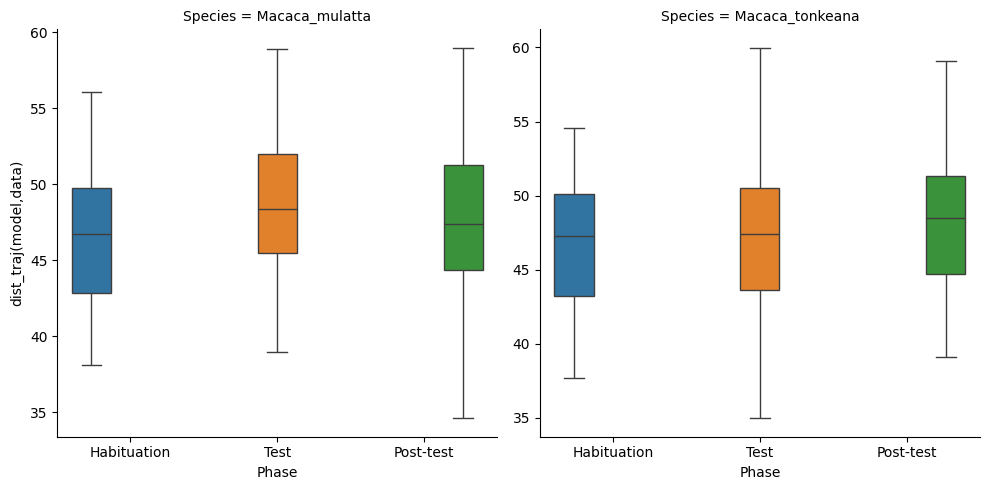

In [24]:
g1 = sns.catplot(x="Phase",y="dist_traj(model,data)",col='Species',data=compare_dist_trajs,kind='box',dodge=True,col_wrap=2,sharey=False,palette='tab10',order=phase_order)
g1.savefig(fig_dir+"distance_between_trajectories.png")